# Mini Project Notebook: Employee Attrition Prediction
## PRASHANTH KANNADAGULI
### SENIOR DATA SCIENCE TRAINER

## Problem Statement

To predict employee attrition using CatBoost and XgBoost

## Learning Objectives

At the end of the experiment, you will be able to

* explore the employee attrition dataset
* apply CatBoost and XgBoost on the dataset
* tune the model hyperparameters to improve accuracy
* evaluate the model using suitable metrics


## Introduction

Employee attrition is the gradual reduction in employee numbers. Employee attrition happens when the size of your workforce diminishes over time. This means that employees are leaving faster than they are hired. Employee attrition happens when employees retire, resign, or simply aren't replaced.
Although employee attrition can be company-wide, it may also be confined to specific parts of a business.

Employee attrition can happen for several reasons. These include unhappiness about employee benefits or the pay structure, a lack of employee development opportunities, and even poor conditions in the workplace.

To know more about the factors that lead to employee attrition, refer [here](https://www.betterup.com/blog/employee-attrition#:~:text=Employee%20attrition%20is%20the%20gradual,or%20simply%20aren't%20replaced).


**Gradient Boosted Decision Trees**

* Gradient boosted decision trees (GBDTs) are one of the most important machine learning models.

* GBDTs originate from AdaBoost, an algorithm that ensembles weak learners and uses the majority vote, weighted by their individual accuracy, to solve binary classification problems. The weak learners in this case are decision trees with a single split, called decision stumps.

* Some of the widely used gradient boosted decision trees are XgBoost, CatBoost and LightGBM.

## Dataset

The dataset used for this mini-project is [HR Employee Attrition dataset](https://data.world/aaizemberg/hr-employee-attrition). This dataset is synthetically created by IBM data scientists. There are 35 features and 1470 records.

There are numerical features such as:

* Age
* DistanceFromHome
* EmployeeNumber
* PerformanceRating

There are several categorical features such as:
* JobRole
* EducationField
* Department
* BusinessTravel

Dependent or target feature is 'attrition' which has values as Yes/No.

### Install CatBoost

In [5]:
!pip -qq install catboost

### Import Required Packages

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, metrics
import warnings
warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 100)
%matplotlib inline

## Load the Dataset

**Exercise 1: Read the dataset**

**Hint:** pd.read_csv()

In [7]:
# read the dataset (keep the CSV in the same folder as this notebook; in Colab, upload it first)
df = pd.read_csv('hr_employee_attrition_train.csv')
df.head()

,age,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeecount,employeenumber,environmentsatisfaction,gender,hourlyrate,jobinvolvement,joblevel,jobrole,jobsatisfaction,maritalstatus,monthlyincome,monthlyrate,numcompaniesworked,over18,overtime,percentsalaryhike,performancerating,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,attrition
0,45,Travel_Rarely,556,Research & Development,25,2,Life Sciences,1,1888,2,Female,93,2,2,Manufacturing Director,4,Married,5906,23888,0,Y,No,13,3,4,80,2,10,2,2,9,8,3,8,No
1,34,Travel_Rarely,970,Research & Development,8,2,Medical,1,757,2,Female,96,3,2,Healthcare Representative,3,Single,6142,7360,3,Y,No,11,3,4,80,0,10,2,3,5,1,4,3,No
2,39,Travel_Rarely,360,Research & Development,23,3,Medical,1,1310,3,Male,93,3,1,Research Scientist,1,Single,3904,22154,0,Y,No,13,3,1,80,0,6,2,3,5,2,0,3,Yes
3,26,Travel_Rarely,933,Sales,1,3,Life Sciences,1,476,3,Male,57,3,2,Sales Executive,3,Married,5296,20156,1,Y,No,17,3,2,80,1,8,3,3,8,7,7,7,No
4,40,Travel_Rarely,329,Research & Development,1,4,Life Sciences,1,1361,2,Male,88,3,1,Laboratory Technician,2,Married,2387,6762,3,Y,No,22,4,3,80,1,7,3,3,4,2,0,3,No


In [8]:
# Check the shape of dataframe.
print('Shape of the dataframe:', df.shape)

Shape of the dataframe: (1170, 35)


There can be more than one file to read as this is introduced as a competition, dataset has one file for training the model. Their can be other files as one containing the test features and the other can be the true labels.

## Data Exploration

- Check for missing values
- Check for consistent data type across a feature
- Check for outliers or inconsistencies in data columns
- Check for correlated features
- Do we have a target label imbalance
- How our independent variables are distributed relative to our target label
- Are there features that have strong linear or monotonic relationships? Making correlation heatmaps makes it easy to identify possible collinearity

**Exercise 2: Create a `List` of numerical and categorical columns. Display a statistical description of the dataset. Remove missing values (if any)**

**Hint:** Use `for` to iterate through each column.

In [9]:
target = 'attrition'

# Split the columns into numerical and categorical lists
numerical_cols, categorical_cols = [], []
for col in df.columns:
    if col == target:
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        numerical_cols.append(col)
    else:
        categorical_cols.append(col)

print('Numerical columns  :', len(numerical_cols), numerical_cols)
print('Categorical columns:', len(categorical_cols), categorical_cols)

# Statistical description
display(df.describe().T)
display(df.describe(include='all').T[['count', 'unique', 'top', 'freq']].loc[categorical_cols + [target]])

# Missing values
print('\nMissing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('Total missing values:', df.isnull().sum().sum())
df = df.dropna().reset_index(drop=True)      # remove missing values (if any)
print('Shape after removing missing values:', df.shape)

# Columns with a single value (or pure identifiers) carry no information for the model
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
drop_cols = constant_cols + ['employeenumber']
print('\nDropping non-informative columns:', drop_cols)
df = df.drop(columns=drop_cols)
numerical_cols = [c for c in numerical_cols if c not in drop_cols]
categorical_cols = [c for c in categorical_cols if c not in drop_cols]
print('Shape after dropping them:', df.shape)

Numerical columns  : 26 ['age', 'dailyrate', 'distancefromhome', 'education', 'employeecount', 'employeenumber', 'environmentsatisfaction', 'hourlyrate', 'jobinvolvement', 'joblevel', 'jobsatisfaction', 'monthlyincome', 'monthlyrate', 'numcompaniesworked', 'percentsalaryhike', 'performancerating', 'relationshipsatisfaction', 'standardhours', 'stockoptionlevel', 'totalworkingyears', 'trainingtimeslastyear', 'worklifebalance', 'yearsatcompany', 'yearsincurrentrole', 'yearssincelastpromotion', 'yearswithcurrmanager']
Categorical columns: 8 ['businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus', 'over18', 'overtime']


,count,mean,std,min,25%,50%,75%,max
age,1170.0,36.858120,9.183448,18.0,30.00,35.0,43.00,60.0
dailyrate,1170.0,797.822222,403.592661,102.0,461.00,798.0,1146.75,1499.0
distancefromhome,1170.0,9.262393,8.150868,1.0,2.00,7.0,14.00,29.0
education,1170.0,2.917949,1.011534,1.0,2.00,3.0,4.00,5.0
employeecount,1170.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
employeenumber,1170.0,1021.113675,600.548289,1.0,496.25,1008.5,1548.50,2065.0
environmentsatisfaction,1170.0,2.723932,1.095847,1.0,2.00,3.0,4.00,4.0
hourlyrate,1170.0,65.501709,20.310054,30.0,48.00,66.0,83.00,100.0
jobinvolvement,1170.0,2.747009,0.702625,1.0,2.00,3.0,3.00,4.0
joblevel,1170.0,2.049573,1.096352,1.0,1.00,2.0,3.00,5.0


,count,unique,top,freq
businesstravel,1170,3,Travel_Rarely,831
department,1170,3,Research & Development,767
educationfield,1170,6,Life Sciences,477
gender,1170,2,Male,698
jobrole,1170,9,Sales Executive,258
maritalstatus,1170,3,Married,536
over18,1170,1,Y,1170
overtime,1170,2,No,845
attrition,1170,2,No,981



Missing values per column:
Series([], dtype: int64)
Total missing values: 0
Shape after removing missing values: (1170, 35)

Dropping non-informative columns: ['employeecount', 'over18', 'standardhours', 'employeenumber']
Shape after dropping them: (1170, 31)


First, we want to get a sense of our data:
- What features have the most divergent distributions based on target class
- Do we have a target label imbalance
- How our independent variables are distributed relative to our target label
- Are there features that have strong linear or monotonic relationships, making correlation heatmaps makes it easy to identify possible colinearity

### Check for outliers

**Exercise 3: Create a box plot to check for outliers**

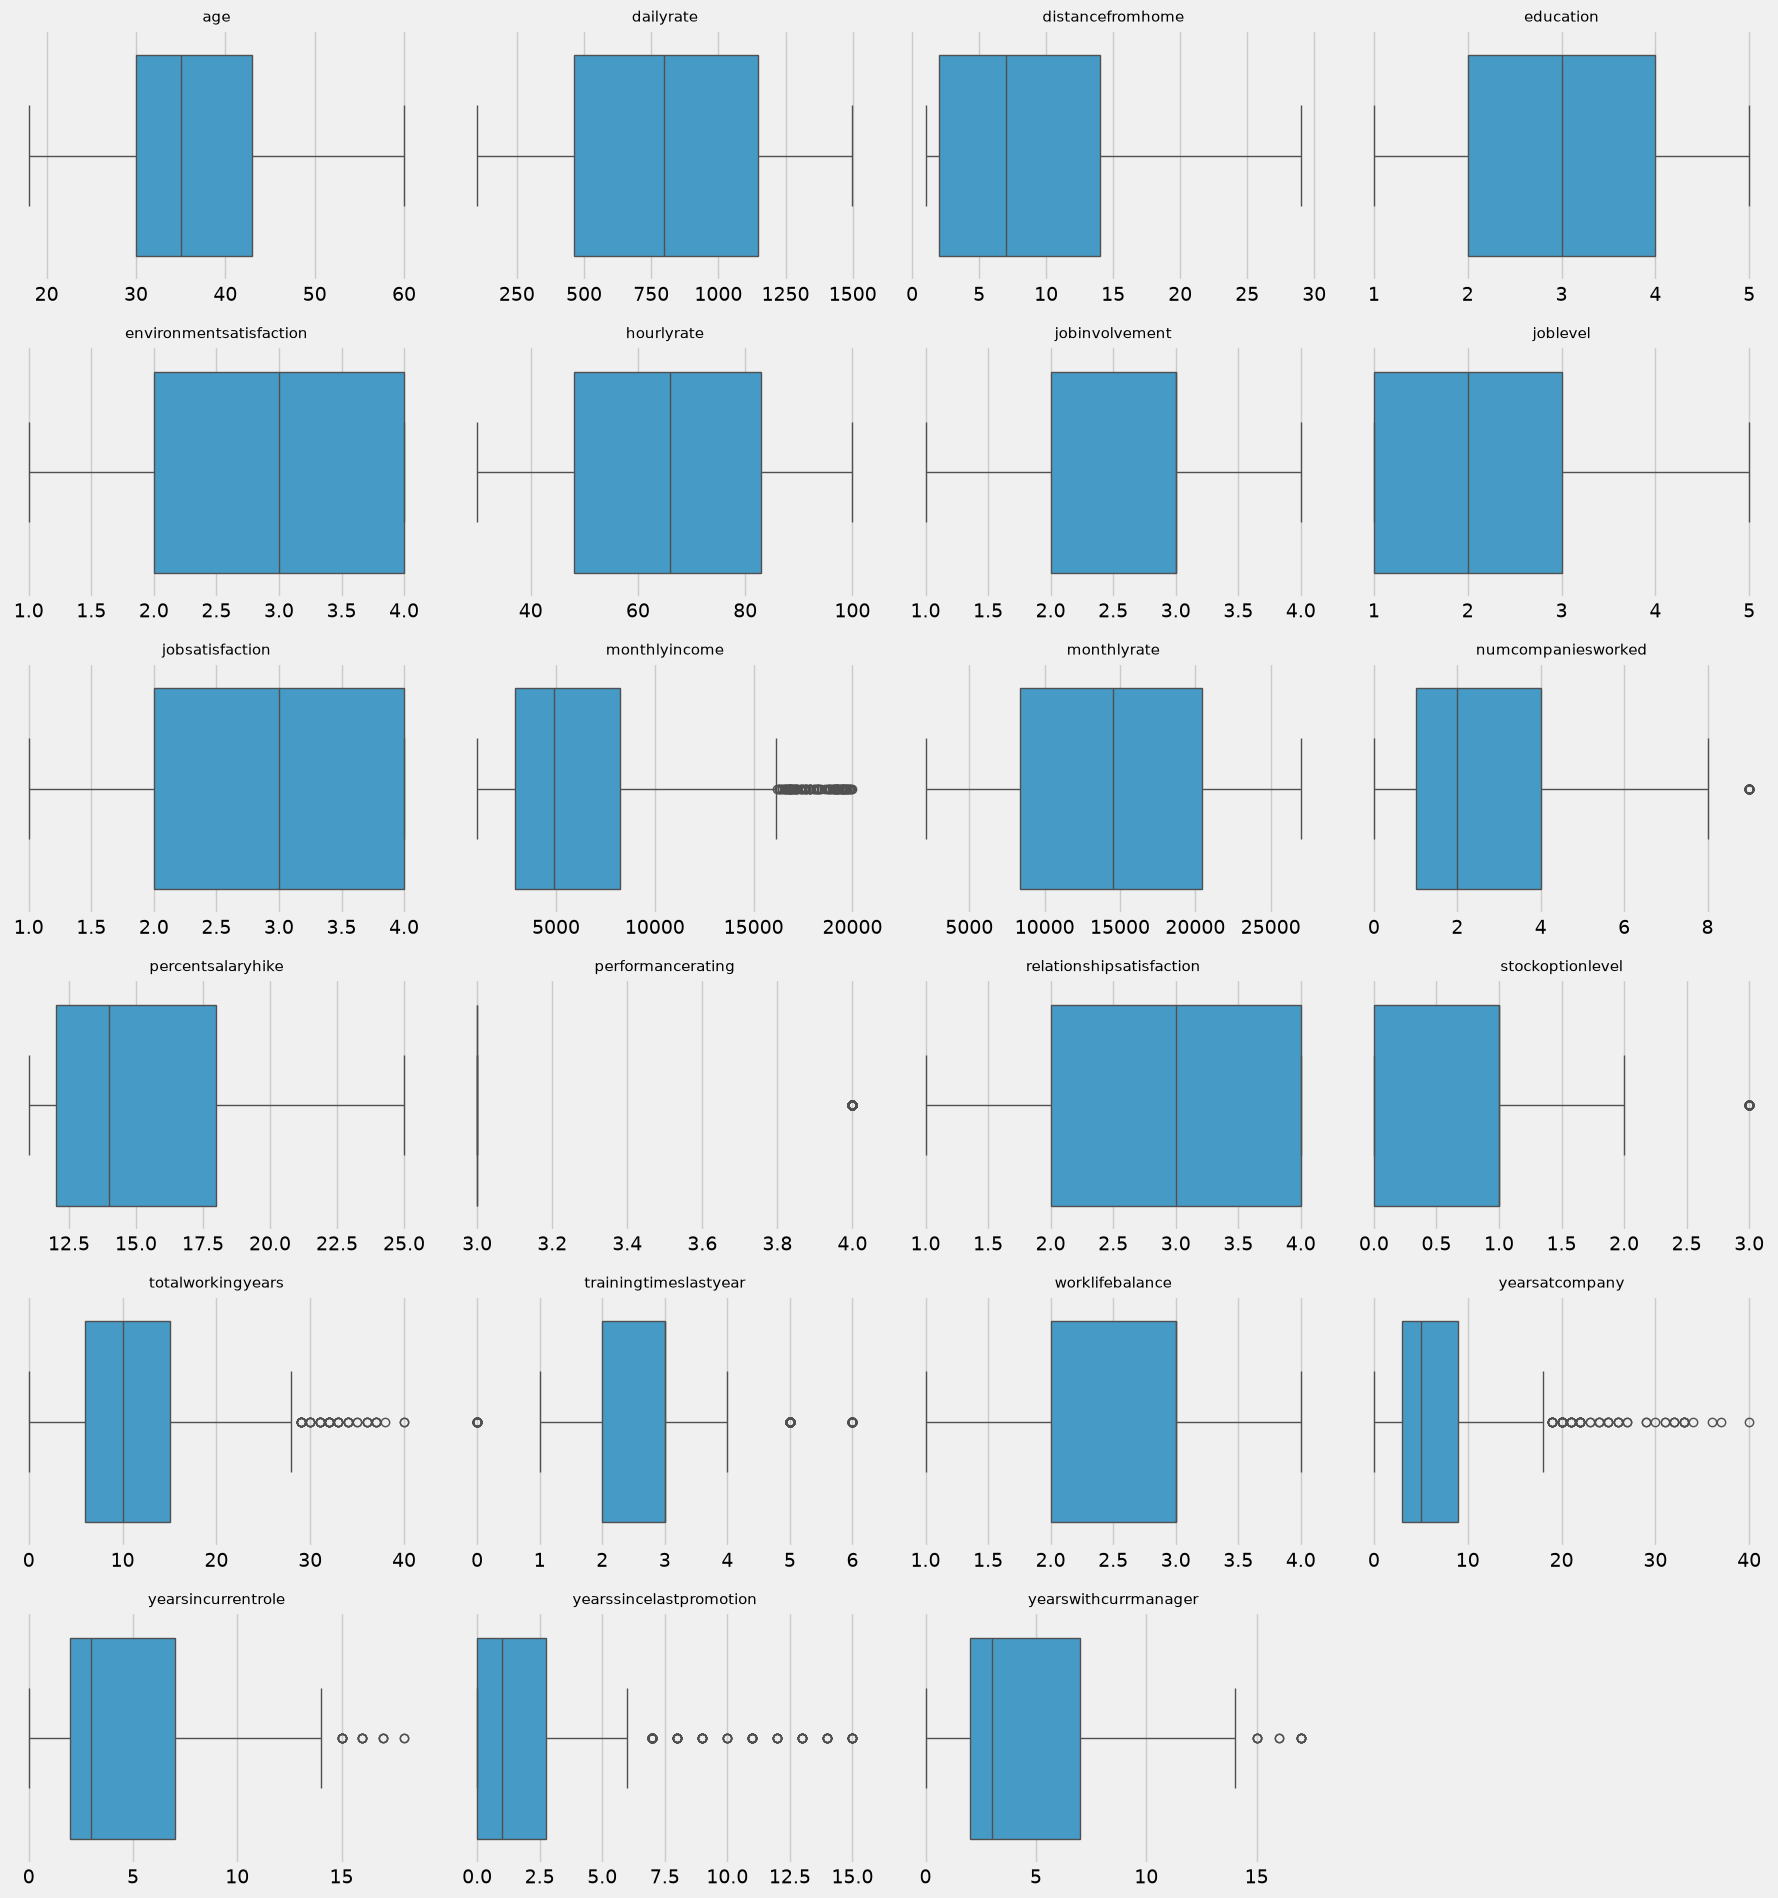

In [63]:
# Check for outliers
n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.2 * n_rows))
for ax, col in zip(axes.ravel(), numerical_cols):
    sns.boxplot(x=df[col], ax=ax, color='#30a2da')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
for ax in axes.ravel()[len(numerical_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

### Handling outliers

**Exercise 4: Use lower bound as 25% and upper bound as 75% to handle the outliers**

In [11]:
# IQR method: lower bound uses the 25th percentile (Q1), upper bound uses the 75th percentile (Q3)
# Outliers are capped (winsorised) at the bounds instead of dropping rows, so no employee records are lost.
# Only continuous-looking columns are treated; small ordinal scales (ratings 1-4 etc.) are left untouched.
df_clean = df.copy()
continuous_cols = [c for c in numerical_cols if df[c].nunique() > 15]

for col in continuous_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out:
        print(f'{col:25s} outliers: {n_out:4d}  bounds: [{lower:9.1f}, {upper:9.1f}]')
    df_clean[col] = df[col].clip(lower, upper)

monthlyincome             outliers:   94  bounds: [  -5036.0,   16166.0]
totalworkingyears         outliers:   55  bounds: [     -7.5,      28.5]
yearsatcompany            outliers:   83  bounds: [     -6.0,      18.0]
yearsincurrentrole        outliers:   17  bounds: [     -5.5,      14.5]
yearssincelastpromotion   outliers:  142  bounds: [     -4.1,       6.9]
yearswithcurrmanager      outliers:   13  bounds: [     -5.5,      14.5]


Outliers remaining per column: {}


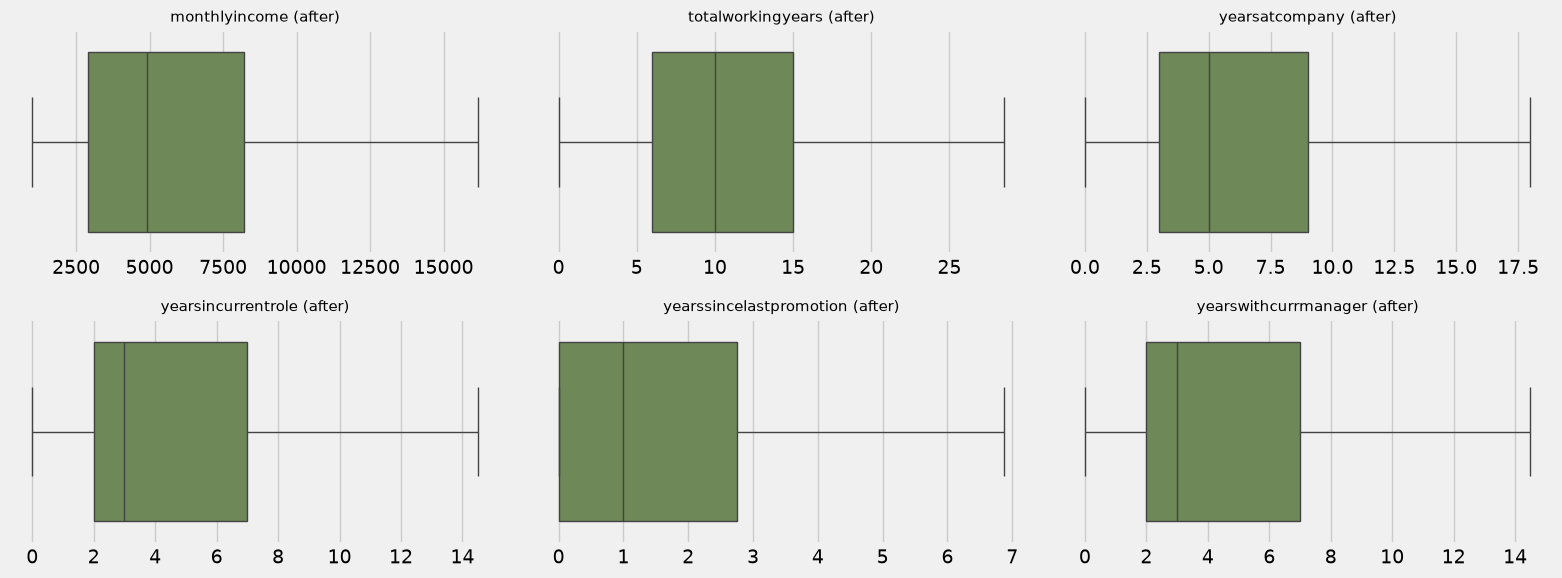

In [12]:
# Recheck for outliers
remaining = {}
for col in continuous_cols:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    remaining[col] = int(((df_clean[col] < Q1 - 1.5 * IQR) | (df_clean[col] > Q3 + 1.5 * IQR)).sum())
print('Outliers remaining per column:', {k: v for k, v in remaining.items() if v})

cols_to_plot = ['monthlyincome', 'totalworkingyears', 'yearsatcompany', 'yearsincurrentrole',
                'yearssincelastpromotion', 'yearswithcurrmanager']
fig, axes = plt.subplots(2, 3, figsize=(16, 6))
for ax, col in zip(axes.ravel(), cols_to_plot):
    sns.boxplot(x=df_clean[col], ax=ax, color='#6d904f')
    ax.set_title(col + ' (after)', fontsize=11)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

### Target label imbalance

**Exercise 5: Check if there is an imbalance in target label**

**Hint:** Use value_counts()

In [13]:
# Count of unique values in Attrition column
counts = df_clean['attrition'].value_counts()
print(counts)
print()
print((df_clean['attrition'].value_counts(normalize=True) * 100).round(2).astype(str) + ' %')

attrition
No     981
Yes    189
Name: count, dtype: int64

attrition
No     83.85 %
Yes    16.15 %
Name: proportion, dtype: object


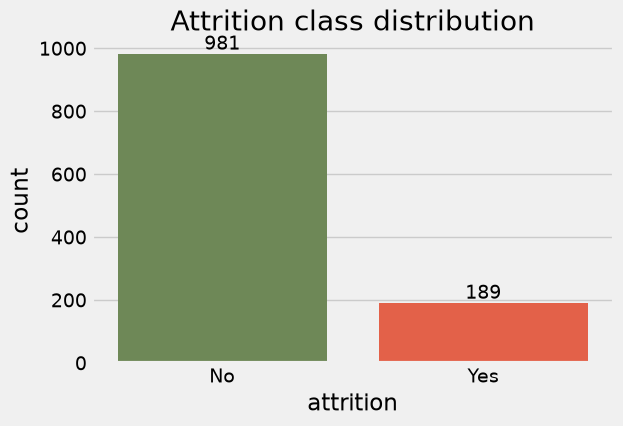

In [14]:
# Plot barplot to visualize balance/imbalance
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='attrition', data=df_clean, palette=['#6d904f', '#fc4f30'])
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.title('Attrition class distribution')
plt.show()

If there is any imbalance in the dataset then a few techniques can be utilised (optional):
1. SMOTE
2. Cross Validation
3. Regularizing the model's parameters

###Plot pairplot

**Exercise 6: Visualize the relationships between the predictor variables and the target variable using a pairplot**

**Hint:** Use sns.pairplot

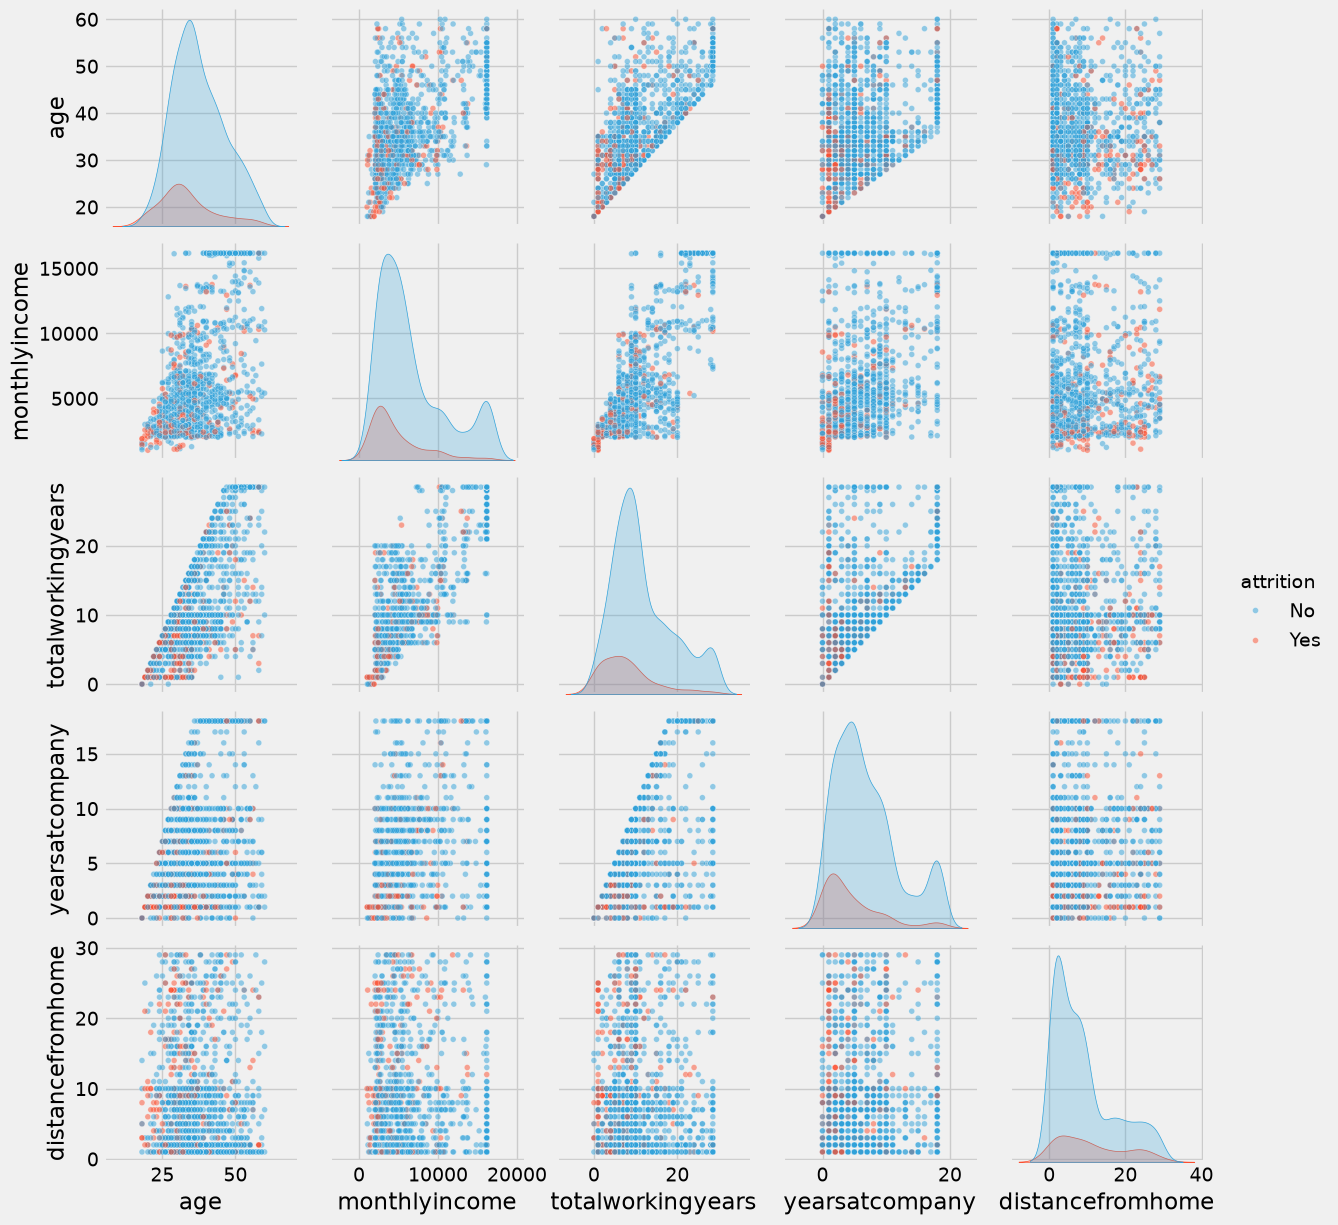

In [53]:
# Visualize a pairplot with relevant features
pair_features = ['age', 'monthlyincome', 'totalworkingyears', 'yearsatcompany', 'distancefromhome', 'attrition']
sns.pairplot(df_clean[pair_features], hue='attrition', palette={'No': '#30a2da', 'Yes': '#fc4f30'},
             diag_kind='kde', plot_kws={'alpha': 0.5, 's': 18})
plt.show()

### Explore Correlation

- Plotting the Heatmap

**Exercise 7: Visualize the correlation among IBM employee attrition numerical features using a heatmap**

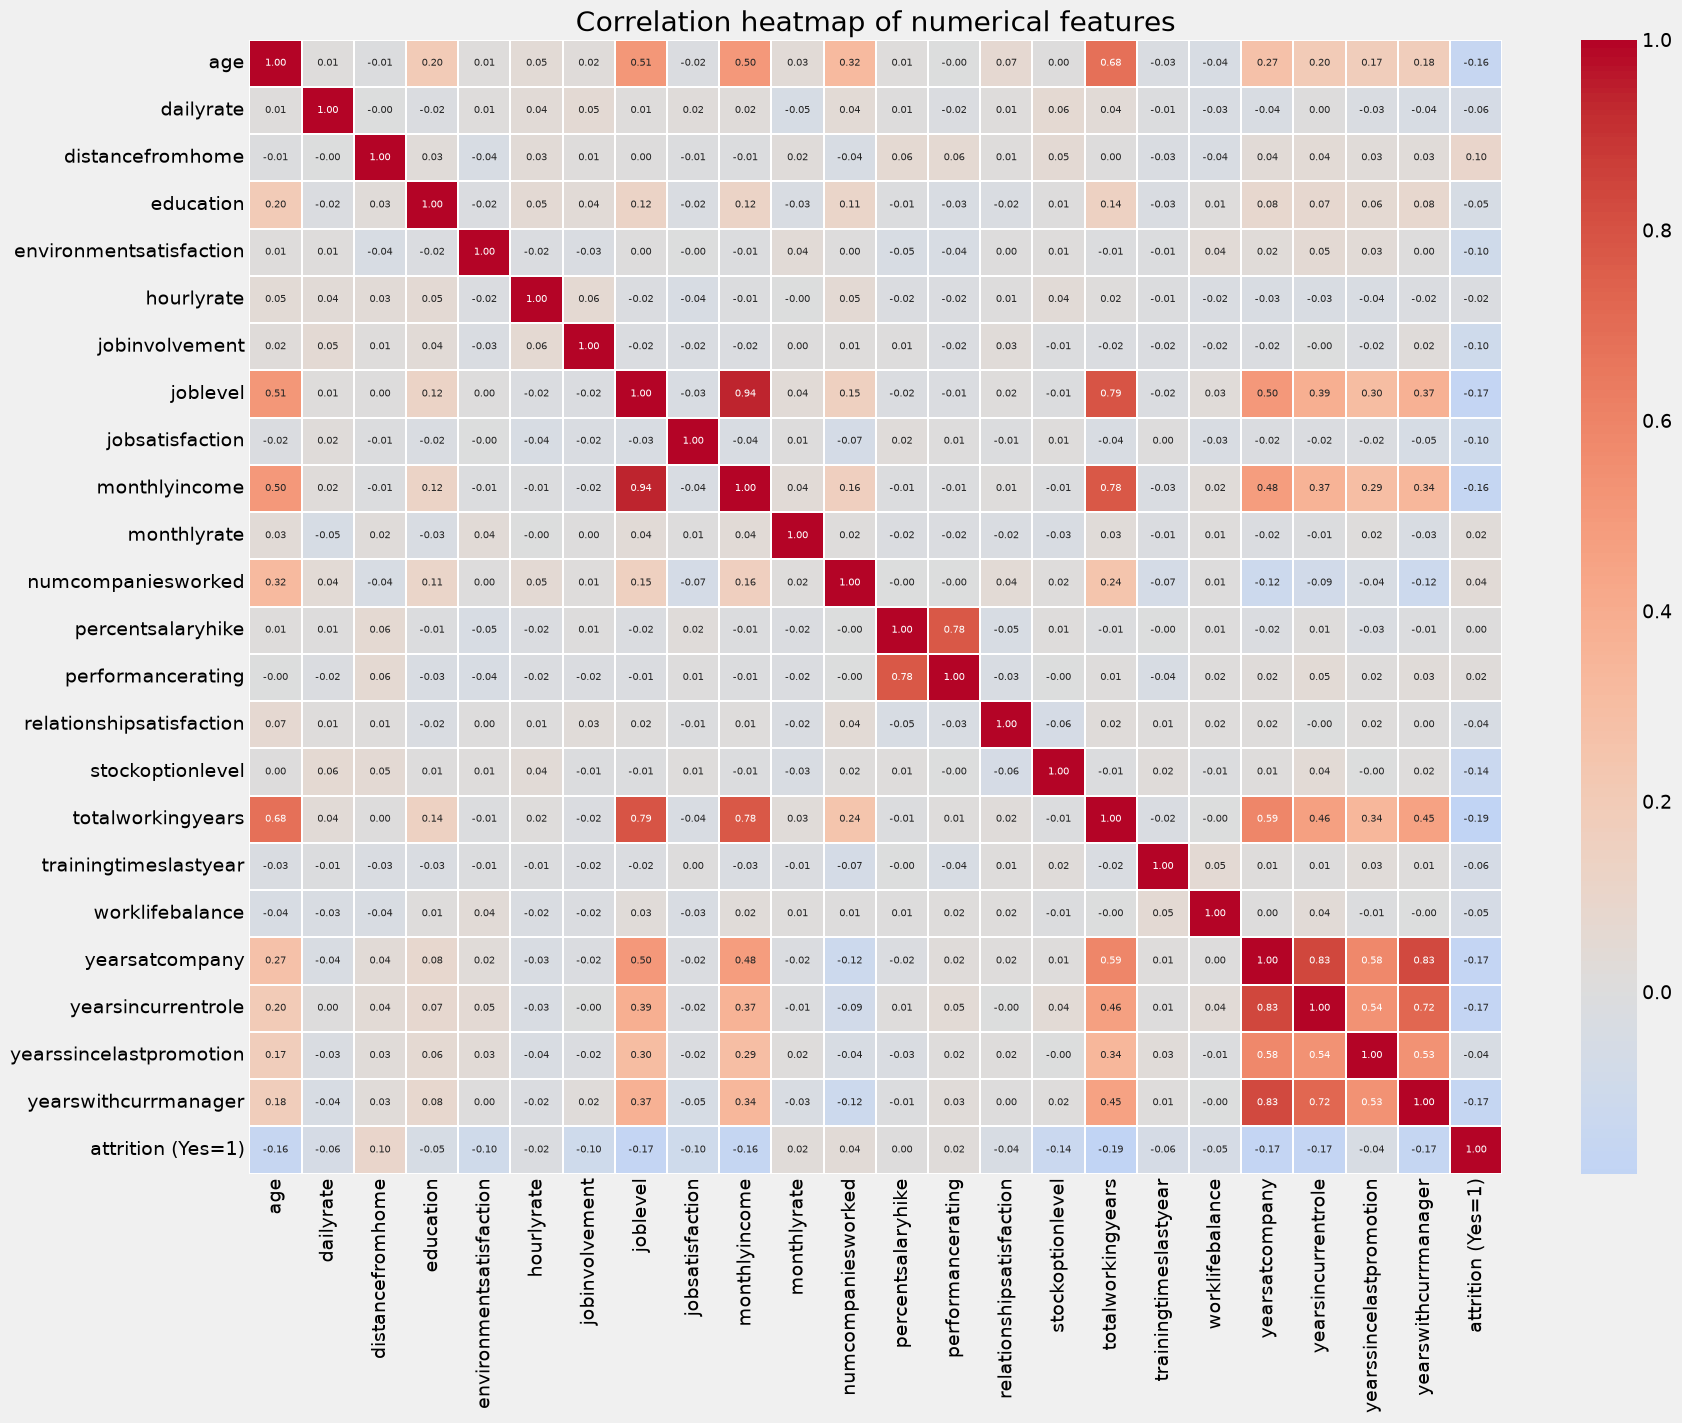

Strongest correlations with attrition:
totalworkingyears      -0.191
yearsincurrentrole     -0.174
yearsatcompany         -0.172
joblevel               -0.168
yearswithcurrmanager   -0.165
monthlyincome          -0.164
age                    -0.160
stockoptionlevel       -0.136
Name: attrition (Yes=1), dtype: float64

Highly correlated feature pairs (|r| > 0.7):
joblevel            monthlyincome           0.943
yearsatcompany      yearsincurrentrole      0.833
                    yearswithcurrmanager    0.830
joblevel            totalworkingyears       0.789
percentsalaryhike   performancerating       0.776
monthlyincome       totalworkingyears       0.776
yearsincurrentrole  yearswithcurrmanager    0.723
dtype: float64


In [16]:
# Visualize heatmap
corr_df = df_clean[numerical_cols].copy()
corr_df['attrition (Yes=1)'] = (df_clean['attrition'] == 'Yes').astype(int)
corr = corr_df.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, fmt='.2f', annot_kws={'size': 7}, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation heatmap of numerical features')
plt.show()

print('Strongest correlations with attrition:')
print(corr['attrition (Yes=1)'].drop('attrition (Yes=1)').sort_values(key=abs, ascending=False).head(8).round(3))

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print('\nHighly correlated feature pairs (|r| > 0.7):')
print(pairs[pairs.abs() > 0.7].sort_values(ascending=False).round(3))

Comment on the observations made with the pairplot and heatmap

**Observations (pairplot and heatmap)**

* **Pairplot:** employees who left (`Yes`) are concentrated at lower `age`, lower `monthlyincome`, fewer `totalworkingyears` and fewer `yearsatcompany`. In the KDE plots the `Yes` curves peak earlier/lower than the `No` curves (median age 31 vs 36, median monthly income about 3,200 vs 5,100, median tenure 3 vs 5 years). `distancefromhome` shows only a slight shift (leavers live a little farther away). There is heavy overlap between the two classes, so no single feature separates them.
* **Heatmap:** every numerical feature has only a weak correlation with attrition (the strongest are `totalworkingyears` -0.19, `yearsincurrentrole` -0.17, `yearsatcompany` -0.17, `joblevel` -0.17, `monthlyincome` -0.16, `age` -0.16). The sign is always negative: more experience, seniority, pay and tenure mean lower attrition.
* **Multicollinearity:** `joblevel`-`monthlyincome` (0.94), `yearsatcompany`-`yearsincurrentrole` (0.83), `yearsatcompany`-`yearswithcurrmanager` (0.83), `joblevel`-`totalworkingyears` (0.79), `percentsalaryhike`-`performancerating` (0.78) and `monthlyincome`-`totalworkingyears` (0.78) are strongly correlated. Tree-based models handle this well, so we keep all of them.
* **Categorical signal (not visible in the heatmap):** attrition is about 31% for employees who work `overtime` vs 10% for those who do not; 26% for `Single` vs about 11-12% for `Married`/`Divorced`; and it ranges from about 3% (Research Director) to 37% (Sales Representative) across `jobrole`.

### Preparing the test feature space
* Remove outliers if any
* Handle the categorical feature if required
* Other processing steps can also be followed.

In [17]:
# Categorical features are handled model-wise below (native handling for CatBoost, one-hot for XGBoost/LightGBM).
# Outliers were already capped and there are no missing values. Here we create ONE stratified
# train / validation / test split (70 / 15 / 15) so that every model is compared on identical rows.
y_all = (df_clean['attrition'] == 'Yes').astype(int)

idx_train, idx_temp = train_test_split(df_clean.index, test_size=0.30, stratify=y_all, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, stratify=y_all.loc[idx_temp], random_state=42)

for name, idx in [('train', idx_train), ('validation', idx_val), ('test', idx_test)]:
    print(f'{name:11s}: {len(idx):4d} rows, attrition rate = {y_all.loc[idx].mean():.3f}')

# Helper used for all three models
results = []

def evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test):
    """Print + store accuracy, ROC-AUC and F1 on train / validation / test sets."""
    row = {'Model': model_name}
    for set_name, X_, y_ in [('Train', X_train, y_train), ('Validation', X_val, y_val), ('Test', X_test, y_test)]:
        pred = model.predict(X_)
        proba = model.predict_proba(X_)[:, 1]
        pred = np.asarray(pred).ravel().astype(int)
        row[f'{set_name} Accuracy'] = accuracy_score(y_, pred)
        row[f'{set_name} ROC-AUC'] = roc_auc_score(y_, proba)
        row[f'{set_name} F1'] = f1_score(y_, pred)
    results.append(row)
    print(pd.DataFrame(row, index=[0]).drop(columns='Model').T.round(4).rename(columns={0: model_name}))
    cm = confusion_matrix(y_test, np.asarray(model.predict(X_test)).ravel().astype(int))
    plt.figure(figsize=(3.6, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'{model_name} - test confusion matrix')
    plt.show()

train      :  819 rows, attrition rate = 0.161
validation :  175 rows, attrition rate = 0.160
test       :  176 rows, attrition rate = 0.165


Optional:
Use `Hyperopt`, a hyperparameter tuning technique to identify the best set of parameters.



In the notebook, data processing is done separately for different models.
Considering the fact that different models may require data in different format and in turn different processes may be followed to process the data.

If the processing steps followed for the models are same, data processing can also be done once.

## Apply CatBoost

Catboost was released in 2017 by Yandex, showing, by their benchmark to be faster in prediction, better in accuracy, and easier to use for categorical data across a series of GBDT tasks. Additional capabilities of catboost include plotting feature interactions and object (row) importance.

[Here](https://catboost.ai/en/docs/) is the official documentation of CatBoost

### Data Processing for CatBoost

**Exercise 8: Data processing for CatBoost**
* **Copy the dataframe that was created after removing the outliers**
* **Handle the categorical features if required**
* **Create target column and feature space**

**Hint:** Column containing the information on attrition will be the target column.

In [18]:
# Copy the data
cb_df = df_clean.copy()
cb_df.head()

,age,businesstravel,dailyrate,department,distancefromhome,education,educationfield,environmentsatisfaction,gender,hourlyrate,jobinvolvement,joblevel,jobrole,jobsatisfaction,maritalstatus,monthlyincome,monthlyrate,numcompaniesworked,overtime,percentsalaryhike,performancerating,relationshipsatisfaction,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,attrition
0,45,Travel_Rarely,556,Research & Development,25,2,Life Sciences,2,Female,93,2,2,Manufacturing Director,4,Married,5906,23888,0,No,13,3,4,2,10.0,2,2,9,8.0,3.000,8.0,No
1,34,Travel_Rarely,970,Research & Development,8,2,Medical,2,Female,96,3,2,Healthcare Representative,3,Single,6142,7360,3,No,11,3,4,0,10.0,2,3,5,1.0,4.000,3.0,No
2,39,Travel_Rarely,360,Research & Development,23,3,Medical,3,Male,93,3,1,Research Scientist,1,Single,3904,22154,0,No,13,3,1,0,6.0,2,3,5,2.0,0.000,3.0,Yes
3,26,Travel_Rarely,933,Sales,1,3,Life Sciences,3,Male,57,3,2,Sales Executive,3,Married,5296,20156,1,No,17,3,2,1,8.0,3,3,8,7.0,6.875,7.0,No
4,40,Travel_Rarely,329,Research & Development,1,4,Life Sciences,2,Male,88,3,1,Laboratory Technician,2,Married,2387,6762,3,No,22,4,3,1,7.0,3,3,4,2.0,0.000,3.0,No


In [19]:
# Target Column
cb_y = (cb_df['attrition'] == 'Yes').astype(int)
cb_y.value_counts()

attrition
0    981
1    189
Name: count, dtype: int64

In [20]:
# Feature Space (CatBoost handles the categorical columns natively - no encoding needed)
cb_X = cb_df.drop(columns='attrition')
cat_features = [c for c in cb_X.columns if c in categorical_cols]
print('Categorical features for CatBoost:', cat_features)

cb_X_train, cb_y_train = cb_X.loc[idx_train], cb_y.loc[idx_train]
cb_X_val,   cb_y_val   = cb_X.loc[idx_val],   cb_y.loc[idx_val]
cb_X_test,  cb_y_test  = cb_X.loc[idx_test],  cb_y.loc[idx_test]
print(cb_X_train.shape, cb_X_val.shape, cb_X_test.shape)

Categorical features for CatBoost: ['businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus', 'overtime']
(819, 30) (175, 30) (176, 30)


### Model Definition

**Exercise 9: Define, train the model and display the results**

**Hint:**
* Use CatBoostClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model. Refer [here](https://catboost.ai/en/docs/concepts/speed-up-training) to see some ways to speedup CatBoost training.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [21]:
# Create CatBoost model
cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=5,
    eval_metric='AUC',
    cat_features=cat_features,
    random_seed=42,
    verbose=100,
)

In [22]:
# Model training (validation set is used to monitor AUC and to keep the best iteration)
cb_model.fit(cb_X_train, cb_y_train,
             eval_set=(cb_X_val, cb_y_val),
             use_best_model=True)
print('Best iteration:', cb_model.get_best_iteration())

0:	test: 0.5847911	best: 0.5847911 (0)	total: 49.8ms	remaining: 24.9s
100:	test: 0.8860544	best: 0.8892128 (76)	total: 201ms	remaining: 792ms
200:	test: 0.9028183	best: 0.9064626 (177)	total: 321ms	remaining: 478ms
300:	test: 0.8982021	best: 0.9103499 (229)	total: 464ms	remaining: 307ms
400:	test: 0.8913994	best: 0.9103499 (229)	total: 610ms	remaining: 151ms
499:	test: 0.8887269	best: 0.9103499 (229)	total: 737ms	remaining: 0us

bestTest = 0.9103498542
bestIteration = 229

Shrink model to first 230 iterations.
Best iteration: 229


### Model performance

                     CatBoost (baseline)
Train Accuracy                    0.9438
Train ROC-AUC                     0.9843
Train F1                          0.7909
Validation Accuracy               0.8800
Validation ROC-AUC                0.9103
Validation F1                     0.4324
Test Accuracy                     0.8523
Test ROC-AUC                      0.7420
Test F1                           0.2778


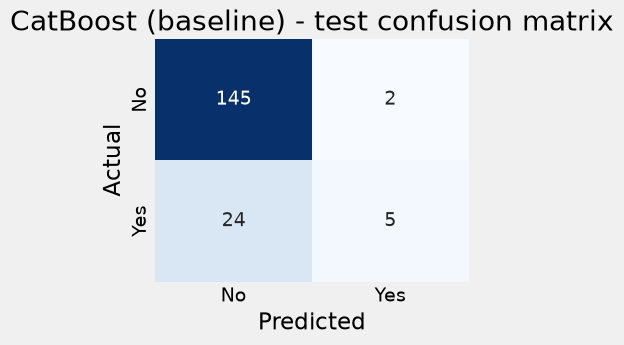

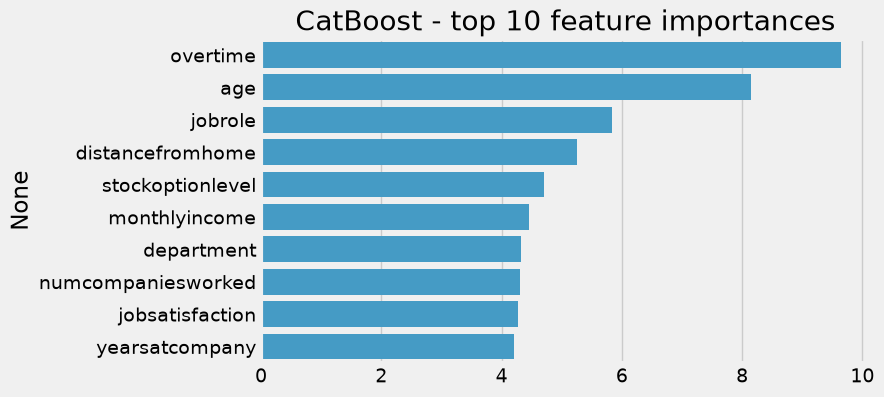

In [23]:
# Model performance on all sets
evaluate_model(cb_model, 'CatBoost (baseline)',
               cb_X_train, cb_y_train, cb_X_val, cb_y_val, cb_X_test, cb_y_test)

# Top features
imp = pd.Series(cb_model.get_feature_importance(), index=cb_X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(7, 4))
sns.barplot(x=imp.values, y=imp.index, color='#30a2da')
plt.title('CatBoost - top 10 feature importances')
plt.show()

### Hyperparameter tuning - CatBoost
A small grid is searched and the combination with the best **validation ROC-AUC** is kept (the test set is never used for choosing parameters). `scale_pos_weight` / class weights help with the class imbalance.

Best validation AUC: 0.9086
Best parameters    : {'class_weights': None, 'depth': 4, 'l2_leaf_reg': 10, 'learning_rate': 0.03}
                     CatBoost (tuned)
Train Accuracy                 0.9060
Train ROC-AUC                  0.9493
Train F1                       0.5926
Validation Accuracy            0.8800
Validation ROC-AUC             0.9086
Validation F1                  0.4000
Test Accuracy                  0.8523
Test ROC-AUC                   0.7666
Test F1                        0.2353


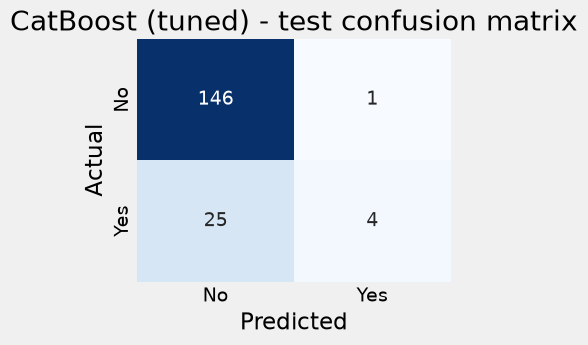

In [24]:
from sklearn.model_selection import ParameterGrid

pos_weight = (cb_y_train == 0).sum() / (cb_y_train == 1).sum()
grid = ParameterGrid({'depth': [3, 4, 6], 'learning_rate': [0.03, 0.08], 'l2_leaf_reg': [3, 10],
                      'class_weights': [None, [1, round(pos_weight, 2)]]})
best_auc, best_params = 0, None
for params in grid:
    m = CatBoostClassifier(iterations=400, eval_metric='AUC', cat_features=cat_features,
                           random_seed=42, verbose=0, **params)
    m.fit(cb_X_train, cb_y_train, eval_set=(cb_X_val, cb_y_val), use_best_model=True)
    auc = roc_auc_score(cb_y_val, m.predict_proba(cb_X_val)[:, 1])
    if auc > best_auc:
        best_auc, best_params = auc, params
print('Best validation AUC:', round(best_auc, 4))
print('Best parameters    :', best_params)

cb_tuned = CatBoostClassifier(iterations=400, eval_metric='AUC', cat_features=cat_features,
                              random_seed=42, verbose=0, **best_params)
cb_tuned.fit(cb_X_train, cb_y_train, eval_set=(cb_X_val, cb_y_val), use_best_model=True)
evaluate_model(cb_tuned, 'CatBoost (tuned)',
               cb_X_train, cb_y_train, cb_X_val, cb_y_val, cb_X_test, cb_y_test)

## Apply XGBoost

XGBoost is a workhorse gradient boosted decision tree algorithm. Its been around since 2014 and has come to dominate the Kaggle and data science community. XGB introduced gradient boosting where new models are fit to the residuals of prior models and then added together, using a gradient descent algorithm to minimize the loss.

Read [here](https://xgboost.readthedocs.io/en/stable/parameter.html) on XGBoost parameters.

Refer [here](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier) for the official documentation of XGBoost classifier.

### Data Processing for XGBoost


**Exercise 10: Data Processing for XGBoost**
* **Copy the dataframe after the outliers were removed.**
* **Handle the categorical features if required**
* **Create target column and feature space**

In [25]:
# Copy dataframe
xgb_df = df_clean.copy()

**Hint:** Use pd.get_dummies

In [26]:
# Handling categorical features (the target 'attrition' is also text, so it is encoded here too)
cat_cols_xgb = xgb_df.select_dtypes(exclude='number').columns.tolist()
print('Columns to encode:', cat_cols_xgb)
dummies = pd.get_dummies(xgb_df[cat_cols_xgb], drop_first=True, dtype=int)
dummies.head()

Columns to encode: ['businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus', 'overtime', 'attrition']


,businesstravel_Travel_Frequently,businesstravel_Travel_Rarely,department_Research & Development,department_Sales,educationfield_Life Sciences,educationfield_Marketing,educationfield_Medical,educationfield_Other,educationfield_Technical Degree,gender_Male,jobrole_Human Resources,jobrole_Laboratory Technician,jobrole_Manager,jobrole_Manufacturing Director,jobrole_Research Director,jobrole_Research Scientist,jobrole_Sales Executive,jobrole_Sales Representative,maritalstatus_Married,maritalstatus_Single,overtime_Yes,attrition_Yes
0,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1
3,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0
4,0,1,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0


In [27]:
# Concat the dummy variables to actual dataframe and remove initial categorical columns
xgb_df = pd.concat([xgb_df.drop(columns=cat_cols_xgb), dummies], axis=1)
# Tree libraries do not accept special characters in feature names
import re
xgb_df.columns = [re.sub(r'[^0-9a-zA-Z_]', '_', c) for c in xgb_df.columns]
print(xgb_df.shape)
xgb_df.head()

(1170, 45)


,age,dailyrate,distancefromhome,education,environmentsatisfaction,hourlyrate,jobinvolvement,joblevel,jobsatisfaction,monthlyincome,monthlyrate,numcompaniesworked,percentsalaryhike,performancerating,relationshipsatisfaction,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,businesstravel_Travel_Frequently,businesstravel_Travel_Rarely,department_Research___Development,department_Sales,educationfield_Life_Sciences,educationfield_Marketing,educationfield_Medical,educationfield_Other,educationfield_Technical_Degree,gender_Male,jobrole_Human_Resources,jobrole_Laboratory_Technician,jobrole_Manager,jobrole_Manufacturing_Director,jobrole_Research_Director,jobrole_Research_Scientist,jobrole_Sales_Executive,jobrole_Sales_Representative,maritalstatus_Married,maritalstatus_Single,overtime_Yes,attrition_Yes
0,45,556,25,2,2,93,2,2,4,5906,23888,0,13,3,4,2,10.0,2,2,9,8.0,3.000,8.0,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,34,970,8,2,2,96,3,2,3,6142,7360,3,11,3,4,0,10.0,2,3,5,1.0,4.000,3.0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,39,360,23,3,3,93,3,1,1,3904,22154,0,13,3,1,0,6.0,2,3,5,2.0,0.000,3.0,0,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1
3,26,933,1,3,3,57,3,2,3,5296,20156,1,17,3,2,1,8.0,3,3,8,7.0,6.875,7.0,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0
4,40,329,1,4,2,88,3,1,2,2387,6762,3,22,4,3,1,7.0,3,3,4,2.0,0.000,3.0,0,1,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0


When creating the dummy variables, the name of attrition column was changed, rename to 'attrition' again.

**Hint:** Use .rename

In [28]:
# Rename target column
xgb_df = xgb_df.rename(columns={'attrition_Yes': 'attrition'})
print('attrition' in xgb_df.columns)

True


In [29]:
# Feature Space
xgb_X = xgb_df.drop(columns='attrition')

# Targer label
xgb_y = xgb_df['attrition']

xgb_X_train, xgb_y_train = xgb_X.loc[idx_train], xgb_y.loc[idx_train]
xgb_X_val,   xgb_y_val   = xgb_X.loc[idx_val],   xgb_y.loc[idx_val]
xgb_X_test,  xgb_y_test  = xgb_X.loc[idx_test],  xgb_y.loc[idx_test]
print(xgb_X_train.shape, xgb_X_val.shape, xgb_X_test.shape)

(819, 44) (175, 44) (176, 44)


### Model Definition

**Exercise 11: Define, train the model and display the results**

**Hint:**
* Use XGBClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [30]:
# Create XGBoost classifier model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5,
    eval_metric='auc',
    random_state=42,
)

In [31]:
# Model training
xgb_model.fit(xgb_X_train, xgb_y_train,
              eval_set=[(xgb_X_val, xgb_y_val)],
              verbose=False)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Model Performance

                     XGBoost (baseline)
Train Accuracy                   0.9634
Train ROC-AUC                    0.9913
Train F1                         0.8729
Validation Accuracy              0.8514
Validation ROC-AUC               0.9009
Validation F1                    0.3810
Test Accuracy                    0.8409
Test ROC-AUC                     0.7417
Test F1                          0.3000


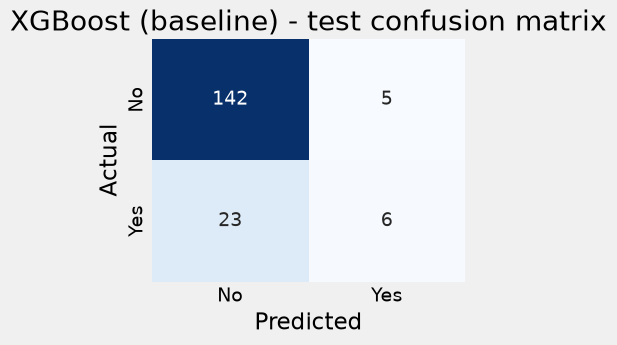

In [32]:
# Model performance on all sets
evaluate_model(xgb_model, 'XGBoost (baseline)',
               xgb_X_train, xgb_y_train, xgb_X_val, xgb_y_val, xgb_X_test, xgb_y_test)

### Hyperparameter tuning - XGBoost
A small grid is searched and the combination with the best **validation ROC-AUC** is kept (the test set is never used for choosing parameters). `scale_pos_weight` / class weights help with the class imbalance.

Best validation AUC: 0.9159
Best parameters    : {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 400, 'scale_pos_weight': 1}
                     XGBoost (tuned)
Train Accuracy                0.9170
Train ROC-AUC                 0.9414
Train F1                      0.6699
Validation Accuracy           0.8686
Validation ROC-AUC            0.9159
Validation F1                 0.4390
Test Accuracy                 0.8466
Test ROC-AUC                  0.7567
Test F1                       0.2703


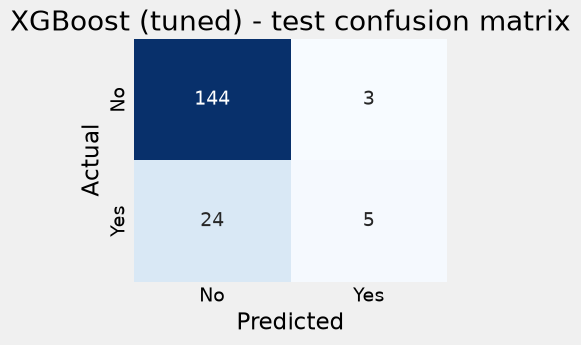

In [33]:
pos_weight_x = (xgb_y_train == 0).sum() / (xgb_y_train == 1).sum()
grid = ParameterGrid({'max_depth': [2, 3, 4], 'learning_rate': [0.03, 0.08], 'n_estimators': [200, 400],
                      'min_child_weight': [1, 5], 'scale_pos_weight': [1, round(pos_weight_x, 2)]})
best_auc, best_params = 0, None
for params in grid:
    m = XGBClassifier(subsample=0.8, colsample_bytree=0.8, reg_lambda=5, random_state=42, **params)
    m.fit(xgb_X_train, xgb_y_train)
    auc = roc_auc_score(xgb_y_val, m.predict_proba(xgb_X_val)[:, 1])
    if auc > best_auc:
        best_auc, best_params = auc, params
print('Best validation AUC:', round(best_auc, 4))
print('Best parameters    :', best_params)

xgb_tuned = XGBClassifier(subsample=0.8, colsample_bytree=0.8, reg_lambda=5, random_state=42, **best_params)
xgb_tuned.fit(xgb_X_train, xgb_y_train)
evaluate_model(xgb_tuned, 'XGBoost (tuned)',
               xgb_X_train, xgb_y_train, xgb_X_val, xgb_y_val, xgb_X_test, xgb_y_test)

## Apply LightGBM

LightGBM is an open-source GBDT framework created by Microsoft as a fast and scalable alternative to XGB and GBM. By default LightGBM will train a Gradient Boosted Decision Tree (GBDT), but it also supports random forests, Dropouts meet Multiple Additive Regression Trees (DART), and Gradient Based One-Side Sampling (Goss).

To know more about LightGBM parameters, refer [here](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html#lightgbm.LGBMClassifier).

### Feature Engineering for LightGBM

In [34]:
## Following the same procedure as followed in XGBoost

# Copy the dataframe
lgb_df = df_clean.copy()

# Handling categorical features
cat_cols_lgb = lgb_df.select_dtypes(exclude='number').columns.tolist()
lgb_dummies = pd.get_dummies(lgb_df[cat_cols_lgb], drop_first=True, dtype=int)

# Concat the dummy variables to actual dataframe and remove initial categorical columns
lgb_df = pd.concat([lgb_df.drop(columns=cat_cols_lgb), lgb_dummies], axis=1)
lgb_df.columns = [re.sub(r'[^0-9a-zA-Z_]', '_', c) for c in lgb_df.columns]

# Rename target column
lgb_df = lgb_df.rename(columns={'attrition_Yes': 'attrition'})

# Features Space
lgb_X = lgb_df.drop(columns='attrition')

# Target Label
lgb_y = lgb_df['attrition']

lgb_X_train, lgb_y_train = lgb_X.loc[idx_train], lgb_y.loc[idx_train]
lgb_X_val,   lgb_y_val   = lgb_X.loc[idx_val],   lgb_y.loc[idx_val]
lgb_X_test,  lgb_y_test  = lgb_X.loc[idx_test],  lgb_y.loc[idx_test]
print(lgb_X_train.shape, lgb_X_val.shape, lgb_X_test.shape)

(819, 44) (175, 44) (176, 44)


### Model Definition

**Hint:**
* Use LGBMClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [35]:
# Create LightGBM classifier model
lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    max_depth=4,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_lambda=5,
    random_state=42,
    verbose=-1,
)

In [36]:
# Model training
lgb_model.fit(lgb_X_train, lgb_y_train,
              eval_set=[(lgb_X_val, lgb_y_val)],
              eval_metric='auc')

,num_leaves,15
,max_depth,4
,learning_rate,0.05
,n_estimators,300
,subsample,0.8
,subsample_freq,1
,colsample_bytree,0.8
,reg_lambda,5
,random_state,42
,verbose,-1
,boosting_type,'gbdt'


### Model performance

                     LightGBM (baseline)
Train Accuracy                    0.9841
Train ROC-AUC                     0.9988
Train F1                          0.9482
Validation Accuracy               0.8800
Validation ROC-AUC                0.8943
Validation F1                     0.4878
Test Accuracy                     0.8466
Test ROC-AUC                      0.7373
Test F1                           0.3077


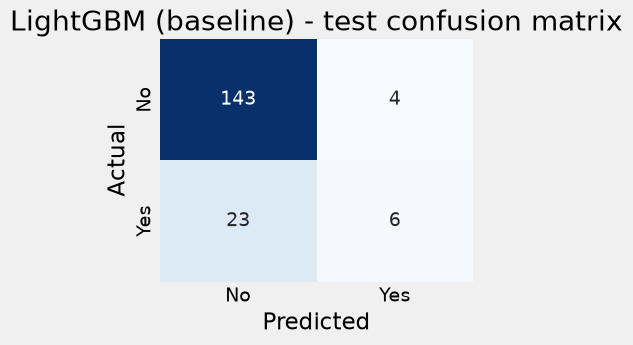

In [37]:
# Model performance on all sets
evaluate_model(lgb_model, 'LightGBM (baseline)',
               lgb_X_train, lgb_y_train, lgb_X_val, lgb_y_val, lgb_X_test, lgb_y_test)

### Hyperparameter tuning - LightGBM
A small grid is searched and the combination with the best **validation ROC-AUC** is kept (the test set is never used for choosing parameters). `scale_pos_weight` / class weights help with the class imbalance.

Best validation AUC: 0.915
Best parameters    : {'learning_rate': 0.03, 'min_child_samples': 30, 'n_estimators': 400, 'num_leaves': 7, 'scale_pos_weight': 1}
                     LightGBM (tuned)
Train Accuracy                 0.9573
Train ROC-AUC                  0.9841
Train F1                       0.8498
Validation Accuracy            0.8686
Validation ROC-AUC             0.9150
Validation F1                  0.4390
Test Accuracy                  0.8409
Test ROC-AUC                   0.7396
Test F1                        0.3333


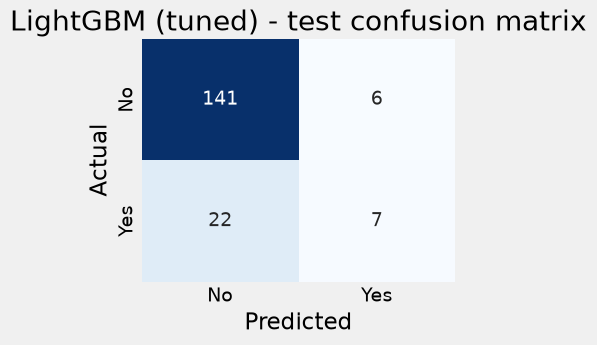

In [38]:
pos_weight_l = (lgb_y_train == 0).sum() / (lgb_y_train == 1).sum()
grid = ParameterGrid({'num_leaves': [7, 15], 'learning_rate': [0.03, 0.08], 'n_estimators': [200, 400],
                      'min_child_samples': [10, 30], 'scale_pos_weight': [1, round(pos_weight_l, 2)]})
best_auc, best_params = 0, None
for params in grid:
    m = LGBMClassifier(max_depth=4, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                       reg_lambda=5, random_state=42, verbose=-1, **params)
    m.fit(lgb_X_train, lgb_y_train)
    auc = roc_auc_score(lgb_y_val, m.predict_proba(lgb_X_val)[:, 1])
    if auc > best_auc:
        best_auc, best_params = auc, params
print('Best validation AUC:', round(best_auc, 4))
print('Best parameters    :', best_params)

lgb_tuned = LGBMClassifier(max_depth=4, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                           reg_lambda=5, random_state=42, verbose=-1, **best_params)
lgb_tuned.fit(lgb_X_train, lgb_y_train)
evaluate_model(lgb_tuned, 'LightGBM (tuned)',
               lgb_X_train, lgb_y_train, lgb_X_val, lgb_y_val, lgb_X_test, lgb_y_test)

## Results

**Exercise 12: Create a dataframe of XGBoost results and CatBoost results and display them**

**Hint:** Use pd.DataFrame

,Train Accuracy,Train ROC-AUC,Train F1,Validation Accuracy,Validation ROC-AUC,Validation F1,Test Accuracy,Test ROC-AUC,Test F1
Model,,,,,,,,,
CatBoost (baseline),0.9438,0.9843,0.7909,0.8800,0.9103,0.4324,0.8523,0.7420,0.2778
CatBoost (tuned),0.9060,0.9493,0.5926,0.8800,0.9086,0.4000,0.8523,0.7666,0.2353
XGBoost (baseline),0.9634,0.9913,0.8729,0.8514,0.9009,0.3810,0.8409,0.7417,0.3000
XGBoost (tuned),0.9170,0.9414,0.6699,0.8686,0.9159,0.4390,0.8466,0.7567,0.2703
LightGBM (baseline),0.9841,0.9988,0.9482,0.8800,0.8943,0.4878,0.8466,0.7373,0.3077
LightGBM (tuned),0.9573,0.9841,0.8498,0.8686,0.9150,0.4390,0.8409,0.7396,0.3333


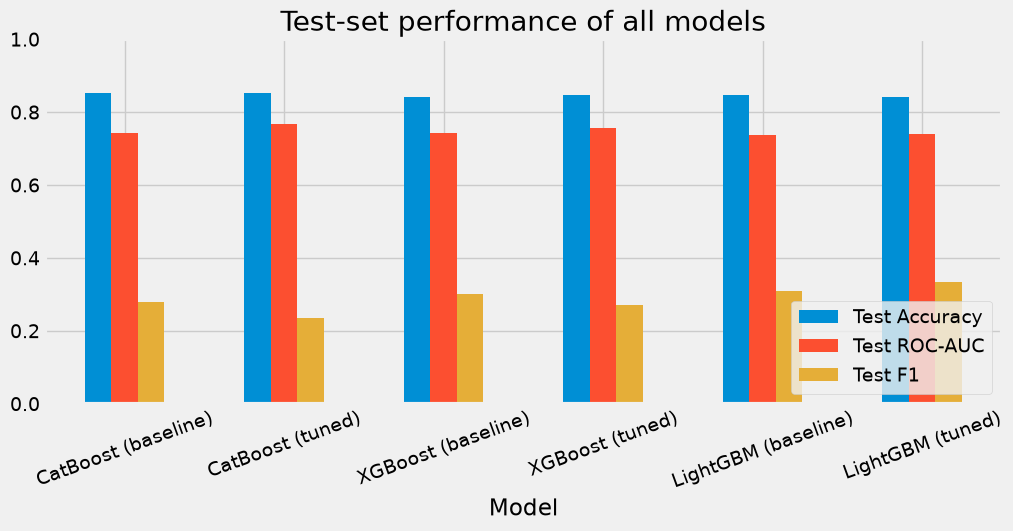

Best model on test ROC-AUC: CatBoost (tuned)


In [39]:
# Create a dataframe for computed metrics for different models
results_df = pd.DataFrame(results).set_index('Model').round(4)
display(results_df)

# Test-set comparison chart
test_cols = ['Test Accuracy', 'Test ROC-AUC', 'Test F1']
results_df[test_cols].plot(kind='bar', figsize=(11, 4.5), rot=20)
plt.title('Test-set performance of all models')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

best = results_df['Test ROC-AUC'].idxmax()
print('Best model on test ROC-AUC:', best)

In [40]:
# 5-fold stratified cross-validation on the full data: a more reliable comparison than one small test set
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cb_cv_params = cb_tuned.get_params()
cb_cv_params['iterations'] = cb_tuned.get_best_iteration() + 1
cv_models = {
    'CatBoost (tuned)': (lambda: CatBoostClassifier(**cb_cv_params), cb_X, cb_y),
    'XGBoost (tuned)': (lambda: XGBClassifier(**xgb_tuned.get_params()), xgb_X, xgb_y),
    'LightGBM (tuned)': (lambda: LGBMClassifier(**lgb_tuned.get_params()), lgb_X, lgb_y),
}
cv_scores = {}
for name, (make_model, X_, y_) in cv_models.items():
    scores = []
    for tr, te in skf.split(X_, y_):
        mdl = make_model()
        mdl.fit(X_.iloc[tr], y_.iloc[tr])
        scores.append(roc_auc_score(y_.iloc[te], mdl.predict_proba(X_.iloc[te])[:, 1]))
    cv_scores[name] = np.array(scores)
    print(f'{name:18s} 5-fold ROC-AUC: {cv_scores[name].mean():.4f} (+/- {cv_scores[name].std():.4f})')

CatBoost (tuned)   5-fold ROC-AUC: 0.8321 (+/- 0.0222)
XGBoost (tuned)    5-fold ROC-AUC: 0.8341 (+/- 0.0281)
LightGBM (tuned)   5-fold ROC-AUC: 0.8325 (+/- 0.0264)


## Conclusion

* **Class imbalance:** only about 16% of employees left, so accuracy alone is misleading (always predicting "No" already gives about 84%). ROC-AUC and F1 are better yardsticks.
* **Baseline vs tuned:** the untuned LightGBM and XGBoost overfit heavily (train ROC-AUC 0.99+ vs test about 0.74). Tuning (shallower trees, smaller learning rate, stronger regularisation) shrinks that train-test gap and slightly improves test ROC-AUC for CatBoost and XGBoost.
* **Model comparison:** the three libraries finish within a few points of each other, with tuned CatBoost highest on test ROC-AUC. The test set has only about 29 employees who left, so one or two predictions change F1 a lot; the gap between validation AUC (about 0.91) and test AUC (about 0.75) is largely this small-sample noise. The 5-fold cross-validated AUC above is the more reliable comparison: all three tuned models land at about 0.83 (differences under 0.003, far smaller than the fold-to-fold spread of about 0.02-0.03), so none is clearly better on this dataset.
* **Main drivers of attrition:** overtime, low income / junior job level, short tenure, young age, being single and certain job roles (sales representatives, lab technicians, HR).
* **Possible next steps:** SMOTE or threshold tuning to raise recall of leavers, Hyperopt/Optuna for a wider search, and SHAP for per-employee explanations.

Reference reading:
1. https://machinelearningmastery.com/xgboost-for-imbalanced-classification/